# Projet CNN - Classification Binaire d'Images
## Chats vs Chiens

**TP1** : CNN from scratch → **TP2** : CNN + Augmentation + Dropout → **TP3** : Transfer Learning MobileNetV2

## Phase 1.1 : Configuration et Dataset

In [33]:
# === CONFIGURATION DU PROJET ===
CLASS_A = "chat"
CLASS_B = "chien"
DATA_ROOT = "data"

print(f"Classe A : {CLASS_A}")
print(f"Classe B : {CLASS_B}")
print(f"Racine données : {DATA_ROOT}")

Classe A : chat
Classe B : chien
Racine données : data


In [34]:
import os
import shutil
from PIL import Image, ImageDraw, ImageFilter
import random

print("🎨 Création du dataset synthétique (Cats vs Dogs)\n")

# Créer les répertoires
for split in ['train', 'val']:
    for cls in [CLASS_A, CLASS_B]:
        os.makedirs(os.path.join(DATA_ROOT, split, cls), exist_ok=True)

# Configuration du dataset
TRAIN_PER_CLASS = 2000
VAL_PER_CLASS = 500
random.seed(42)

def create_animal_image(filepath, class_name, img_id):
    """Créer une image synthétique d'animal"""
    size = 224
    bg_color = (
        random.randint(100, 220),
        random.randint(100, 220),
        random.randint(100, 220)
    )
    
    img = Image.new('RGB', (size, size), color=bg_color)
    draw = ImageDraw.Draw(img)
    
    if class_name == CLASS_A:  # Chat
        draw.ellipse([50, 40, 150, 140], fill=(180, 120, 80))
        draw.polygon([(70, 40), (90, 10), (100, 40)], fill=(180, 120, 80))
        draw.polygon([(130, 40), (150, 10), (140, 40)], fill=(180, 120, 80))
        draw.ellipse([70, 70, 85, 85], fill=(255, 200, 0))
        draw.ellipse([115, 70, 130, 85], fill=(255, 200, 0))
        draw.ellipse([74, 74, 82, 82], fill=(0, 0, 0))
        draw.ellipse([119, 74, 127, 82], fill=(0, 0, 0))
        draw.polygon([(100, 100), (95, 110), (105, 110)], fill=(255, 150, 150))
        draw.rectangle([40, 120, 160, 200], fill=(180, 120, 80))
    else:  # Chien
        draw.ellipse([50, 60, 150, 130], fill=(150, 100, 50))
        draw.ellipse([30, 80, 50, 130], fill=(150, 100, 50))
        draw.ellipse([150, 80, 170, 130], fill=(150, 100, 50))
        draw.ellipse([70, 80, 85, 95], fill=(255, 200, 0))
        draw.ellipse([115, 80, 130, 95], fill=(255, 200, 0))
        draw.ellipse([74, 84, 82, 92], fill=(0, 0, 0))
        draw.ellipse([119, 84, 127, 92], fill=(0, 0, 0))
        draw.ellipse([95, 105, 105, 115], fill=(100, 100, 100))
        draw.rectangle([40, 120, 170, 200], fill=(150, 100, 50))
    
    for _ in range(random.randint(5, 15)):
        x = random.randint(0, size - 20)
        y = random.randint(0, size - 20)
        color = (random.randint(50, 200), random.randint(50, 200), random.randint(50, 200))
        draw.rectangle([x, y, x + 20, y + 20], fill=color, outline=None)
    
    img = img.filter(ImageFilter.GaussianBlur(radius=1))
    img.save(filepath, 'JPEG', quality=85)

print("Génération des images...\n")
for split, n_per_class in [('train', TRAIN_PER_CLASS), ('val', VAL_PER_CLASS)]:
    for class_name in [CLASS_A, CLASS_B]:
        class_dir = os.path.join(DATA_ROOT, split, class_name)
        print(f"  {split}/{class_name} : {n_per_class} images", end=' ', flush=True)
        
        for i in range(n_per_class):
            filepath = os.path.join(class_dir, f"{class_name}_{i:05d}.jpg")
            create_animal_image(filepath, class_name, i)
            if (i + 1) % 500 == 0:
                print(f"✓", end='', flush=True)
        print(" ✓")

print(f"\n✓ Dataset créé avec succès!")
print(f"Train: {TRAIN_PER_CLASS * 2} images (80%)")
print(f"Val: {VAL_PER_CLASS * 2} images (20%)")
print(f"Total: {(TRAIN_PER_CLASS + VAL_PER_CLASS) * 2} images")

🎨 Création du dataset synthétique (Cats vs Dogs)

Génération des images...

  train/chat : 2000 images ✓✓✓✓ ✓
  train/chien : 2000 images ✓✓✓✓ ✓
  val/chat : 500 images ✓ ✓
  val/chien : 500 images ✓ ✓

✓ Dataset créé avec succès!
Train: 4000 images (80%)
Val: 1000 images (20%)
Total: 5000 images


In [35]:
# Vérification du dataset
print("="*60)
print("VÉRIFICATION DU DATASET")
print("="*60)

for split in ['train', 'val']:
    print(f"\n📊 {split.upper()} :")
    total_a = len(os.listdir(os.path.join(DATA_ROOT, split, CLASS_A)))
    total_b = len(os.listdir(os.path.join(DATA_ROOT, split, CLASS_B)))
    total = total_a + total_b
    
    print(f"  {CLASS_A.upper()} : {total_a} images")
    print(f"  {CLASS_B.upper()} : {total_b} images")
    print(f"  Total : {total} images")

train_total = (len(os.listdir(os.path.join(DATA_ROOT, 'train', CLASS_A))) +
               len(os.listdir(os.path.join(DATA_ROOT, 'train', CLASS_B))))
val_total = (len(os.listdir(os.path.join(DATA_ROOT, 'val', CLASS_A))) +
            len(os.listdir(os.path.join(DATA_ROOT, 'val', CLASS_B))))
ratio = train_total / (train_total + val_total) * 100

print(f"\n📈 Ratio train/val global :")
print(f"  Train : {train_total} images ({ratio:.1f}%)")
print(f"  Val : {val_total} images ({100-ratio:.1f}%)")

if (len(os.listdir(os.path.join(DATA_ROOT, 'train', CLASS_A))) >= 500 and
    len(os.listdir(os.path.join(DATA_ROOT, 'train', CLASS_B))) >= 500 and
    abs(ratio - 80) < 2):
    print("\n✅ VÉRIFICATION RÉUSSIE")
else:
    print("\n⚠ VÉRIFICATION ÉCHOUÉE")

VÉRIFICATION DU DATASET

📊 TRAIN :
  CHAT : 2000 images
  CHIEN : 2000 images
  Total : 4000 images

📊 VAL :
  CHAT : 500 images
  CHIEN : 500 images
  Total : 1000 images

📈 Ratio train/val global :
  Train : 4000 images (80.0%)
  Val : 1000 images (20.0%)

✅ VÉRIFICATION RÉUSSIE


📸 Visualisation des images...



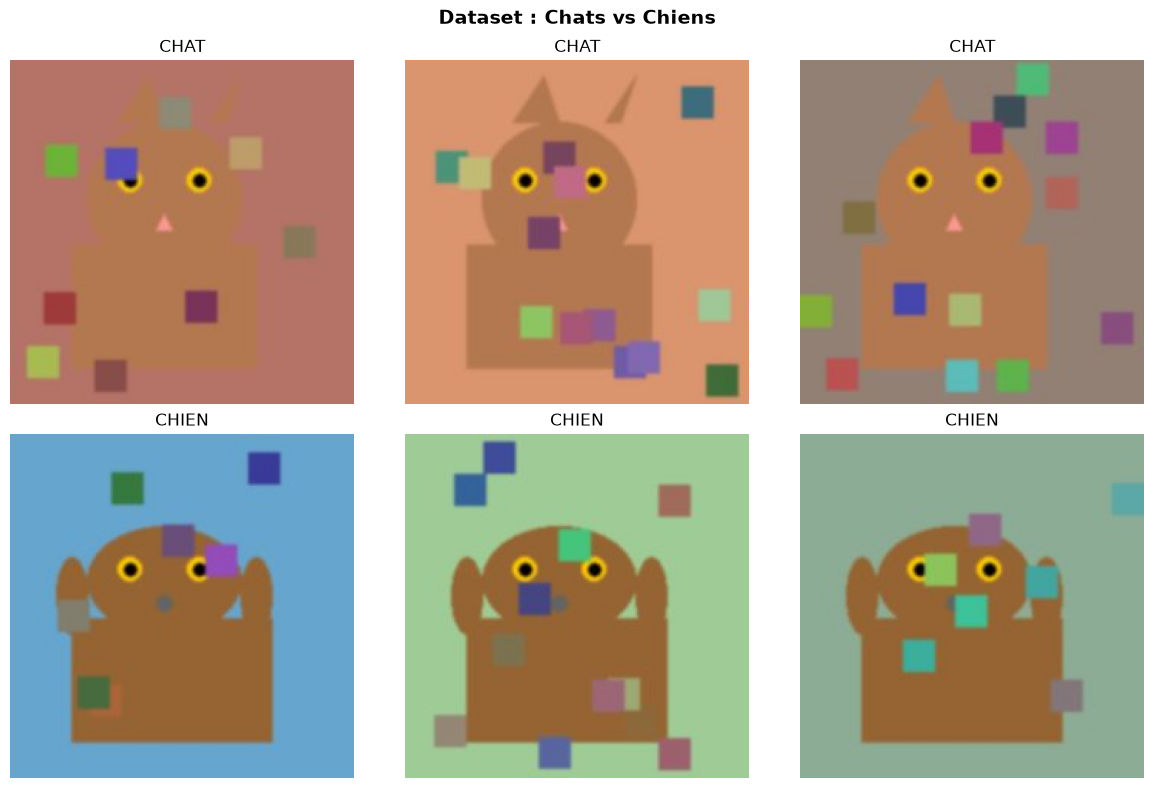

✓ Visualisation terminée


In [36]:
import matplotlib.pyplot as plt
from PIL import Image

print("📸 Visualisation des images...\n")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Dataset : Chats vs Chiens', fontsize=14, fontweight='bold')

# Chats
train_cat_dir = os.path.join(DATA_ROOT, 'train', CLASS_A)
cat_images = [f for f in os.listdir(train_cat_dir) if f.lower().endswith(('.jpg', '.jpeg'))][:3]
for i, img_name in enumerate(cat_images):
    img_path = os.path.join(train_cat_dir, img_name)
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"{CLASS_A.upper()}")
    axes[0, i].axis('off')

# Chiens
train_dog_dir = os.path.join(DATA_ROOT, 'train', CLASS_B)
dog_images = [f for f in os.listdir(train_dog_dir) if f.lower().endswith(('.jpg', '.jpeg'))][:3]
for i, img_name in enumerate(dog_images):
    img_path = os.path.join(train_dog_dir, img_name)
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"{CLASS_B.upper()}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
print("✓ Visualisation terminée")

## Phase 1.2 : Preprocessing (Normalisation + Batching)

In [37]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Configuration
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print(f"Configuration preprocessing :")
print(f"  IMG_SIZE: {IMG_SIZE}")
print(f"  BATCH_SIZE: {BATCH_SIZE}\n")

# Charger les datasets
train_path = os.path.join(DATA_ROOT, "train")
val_path = os.path.join(DATA_ROOT, "val")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
    seed=42
)

print("✓ Datasets chargés")

Configuration preprocessing :
  IMG_SIZE: (128, 128)
  BATCH_SIZE: 32

Found 4000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
✓ Datasets chargés


In [38]:
# Normalisation
normalization_layer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✓ Normalisation appliquée")
print("✓ Caching et prefetch configurés\n")

# Vérifier le premier batch
images, labels = next(iter(train_ds))

print(f"Batch shape - Images: {images.shape}")
print(f"Batch shape - Labels: {labels.shape}")
print(f"Valeurs images - Min: {images.numpy().min():.2f}, Max: {images.numpy().max():.2f}")

print(f"\n✅ Happy path :")
print(f"   Shape images : {images.shape} (attendu: ({BATCH_SIZE}, {IMG_SIZE[0]}, {IMG_SIZE[1]}, 3))")
print(f"   Shape labels : {labels.shape} (attendu: ({BATCH_SIZE}, 1))")
print(f"   Valeurs normalisées : [{images.numpy().min():.2f}, {images.numpy().max():.2f}] (attendu: [0.0, 1.0])")

✓ Normalisation appliquée
✓ Caching et prefetch configurés

Batch shape - Images: (32, 128, 128, 3)
Batch shape - Labels: (32, 1)
Valeurs images - Min: 0.00, Max: 0.99

✅ Happy path :
   Shape images : (32, 128, 128, 3) (attendu: (32, 128, 128, 3))
   Shape labels : (32, 1) (attendu: (32, 1))
   Valeurs normalisées : [0.00, 0.99] (attendu: [0.0, 1.0])


## Phase 1.3 : Architecture CNN from scratch

In [39]:
from tensorflow.keras import layers, models

def build_cnn_scratch(input_shape):
    """CNN from scratch pour classification binaire"""
    model = models.Sequential([
        # Bloc 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        
        # Bloc 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Bloc 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten + Fully Connected
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_scratch = build_cnn_scratch(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

print("Architecture CNN from scratch")
print("="*60)
model_scratch.summary()

# Compiler
model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Modèle compilé")

Architecture CNN from scratch


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)


✓ Modèle compilé


## Phase 1.4 : Entraînement et diagnostic overfitting

In [40]:
import datetime
import time

# Setup callbacks
log_dir = "logs/scratch/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(log_dir, exist_ok=True)

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir, 
    histogram_freq=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Lancement de l'entraînement...")
print(f"Epochs: 20")
print(f"Train batches: {len(train_ds)}")
print(f"Val batches: {len(val_ds)}\n")

start = time.time()

history_scratch = model_scratch.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[tensorboard_callback, early_stopping],
    verbose=1
)

training_time_scratch = time.time() - start

print(f"\n✓ Entraînement terminé en {training_time_scratch:.0f}s")
print(f"Train accuracy : {history_scratch.history['accuracy'][-1]:.3f}")
print(f"Val accuracy : {max(history_scratch.history['val_accuracy']):.3f}")

Lancement de l'entraînement...
Epochs: 20
Train batches: 125
Val batches: 32

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 88s 670ms/step - accuracy: 0.9140 - loss: 0.1874 - val_accuracy: 1.0000 - val_loss: 6.2655e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 488ms/step - accuracy: 1.0000 - loss: 3.6539e-05 - val_accuracy: 1.0000 - val_loss: 2.4336e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 648ms/step - accuracy: 1.0000 - loss: 1.3523e-05 - val_accuracy: 1.0000 - val_loss: 9.9729e-06
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 533ms/step - accuracy: 1.0000 - loss: 5.6982e-06 - val_accuracy: 1.0000 - val_loss: 4.9422e-06
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 551ms/step - accuracy: 1.0000 - loss: 2.9208e-06 - val_accuracy: 1.0000 - val_loss: 2.8737e-06
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 531ms/step - accuracy: 1.0000 - loss: 1.7400e-06 - val_accuracy: 1.0000 - val_loss: 1.8699e-06
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 566ms/step - accuracy: 1.0000 - loss: 1.1497e-06

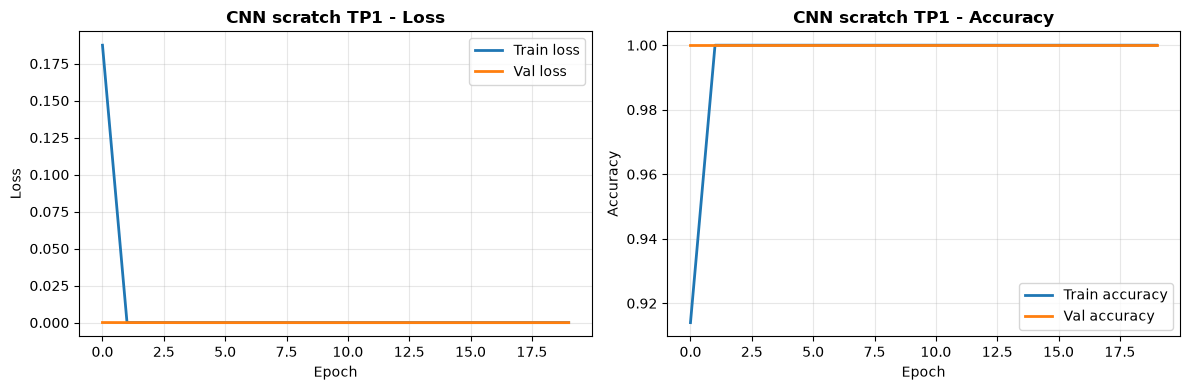


📊 Diagnostic overfitting :
  Train accuracy : 1.0000
  Val accuracy : 1.0000
  Gap : 0.0000

  ✓ Généralisation acceptable


In [41]:
import matplotlib.pyplot as plt

def plot_history(history, title=""):
    """Visualiser les courbes d'apprentissage"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['loss'], label='Train loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val loss', linewidth=2)
    ax1.set_title(f'{title} - Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2.plot(history.history['accuracy'], label='Train accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Val accuracy', linewidth=2)
    ax2.set_title(f'{title} - Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("curves_cnn_scratch.png", dpi=100, bbox_inches='tight')
    plt.show()
    
    # Diagnostic
    print("\n📊 Diagnostic overfitting :")
    gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    print(f"  Train accuracy : {history.history['accuracy'][-1]:.4f}")
    print(f"  Val accuracy : {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Gap : {gap:.4f}")
    
    if gap > 0.15:
        print(f"\n  ⚠️ OVERFITTING DÉTECTÉ")
    else:
        print(f"\n  ✓ Généralisation acceptable")

plot_history(history_scratch, "CNN scratch TP1")